# Phase 9 — Feature Importance & Error Analysis

**What:** open the hood of the champion model (GradientBoosting, threshold 0.25). Two questions:

1. **Which features actually drive the predictions?**
2. **Where does the model go wrong — and why?**

**Why:** a model that scores well on a test set can still fail in ways the average hides.
Feature importance tells us *what* it learned; error analysis tells us *when* it is wrong and
what the mistakes look like — the two views that decide whether this model can be trusted in
production and how to improve it next.

**Honesty note:** the test set was already used once for the final evaluation (Phase 7/8). This
phase only *reads* predictions for diagnostics — no threshold or model choice changes as a
result, so the one-time-evaluation promise still holds.

## 1. Setup

Load the saved champion artifact (pipeline + threshold travel together), the same splits as
every other phase, and the real feature names the model sees after one-hot encoding `Season`.

In [1]:
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

cwd = Path.cwd()
if (cwd / "src").exists():
    BASE = cwd
elif (cwd.parent / "src").exists():
    BASE = cwd.parent
else:
    BASE = cwd
sys.path.insert(0, str(BASE / "src"))
sys.path.insert(0, str(BASE))

from split_data import load_splits
from evaluate import evaluate_model
from analyze import (
    transformed_feature_names,
    impurity_importance,
    permutation_importance_table,
    error_frame,
    error_breakdown,
)

model = joblib.load(BASE / "models" / "karachi_rain_model.pkl")
pipe = model["pipeline"]
threshold = model["threshold"]

X_train, X_test, y_train, y_test = load_splits(BASE / "data" / "processed" / "splits")
feature_names = transformed_feature_names(pipe)

print("Champion:", model["model_name"], "@ threshold", threshold)
metrics = evaluate_model(pipe, X_test, y_test, threshold=threshold)
print("Test metrics:", {k: round(v, 3) for k, v in metrics.items()})
print(f"{len(feature_names)} features in the model")

Champion: GradientBoosting @ threshold 0.25
Test metrics: {'threshold': 0.25, 'accuracy': 0.871, 'precision': 0.734, 'recall': 0.752, 'f1': 0.743}
19 features in the model


## 2. Feature importance — what does the model rely on?

Two very different measures, both shown:

- **Impurity importance** (built into GradientBoosting): how often a feature is used to split
  and how much it lowers impurity. Free to compute, but biased toward features that get used a
  lot even if a substitute would do just as well.
- **Permutation importance**: shuffle a feature and watch the score (ROC-AUC) drop. This is the
  honest question *"if this feature suddenly carried no information, how much would I lose?"*
  Computed on the test set with 5 repeats.

In [2]:
imp = impurity_importance(pipe, feature_names)
imp

,feature,importance
0,WeatherCode,0.295767
1,Rainfall,0.229425
2,CloudCoverage,0.134500
3,Pressure,0.055524
4,WindSpeed,0.046222
5,DayOfYear,0.040519
6,WindDirection,0.036328
7,MinTemperature,0.034436
8,MaxTemperature,0.028495
9,PreviousRainfall,0.025895


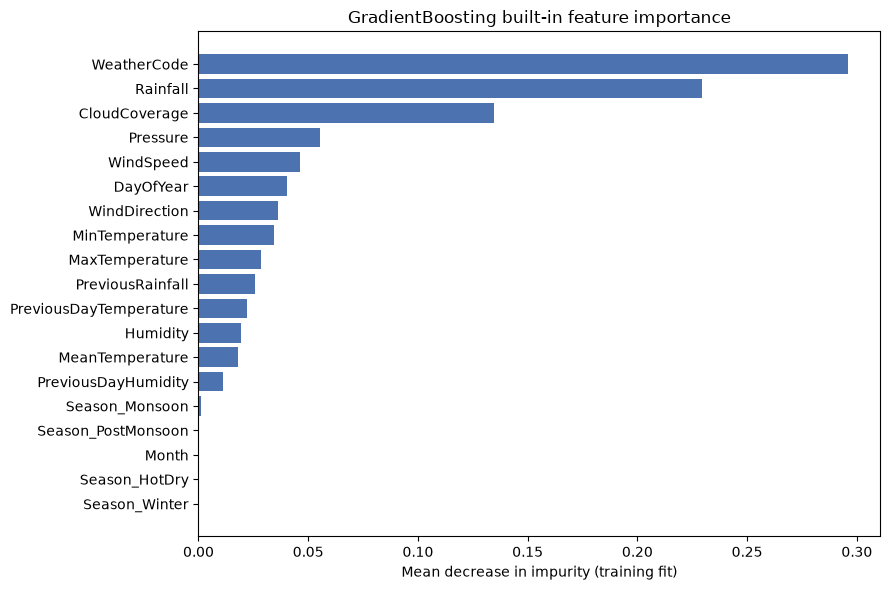

Saved -> G:\Machine Learning Models\1st Model\reports\figures\09_impurity_importance.png


In [3]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp["feature"], imp["importance"], color="#4C72B0")
ax.invert_yaxis()
ax.set_xlabel("Mean decrease in impurity (training fit)")
ax.set_title("GradientBoosting built-in feature importance")
plt.tight_layout()

out = BASE / "reports" / "figures" / "09_impurity_importance.png"
out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out, dpi=120, bbox_inches="tight")
plt.show()
print("Saved ->", out)

In [4]:
# Permutation works on the raw columns the model receives (Season as one
# feature, before one-hot expansion).
perm = permutation_importance_table(pipe, X_test, y_test, n_repeats=5)
perm

,feature,importance_mean,importance_std
0,MinTemperature,0.060258,0.001479
1,CloudCoverage,0.057140,0.003526
2,Rainfall,0.016296,0.002949
3,Pressure,0.014655,0.001020
4,MaxTemperature,0.012770,0.002485
5,MeanTemperature,0.010513,0.001479
6,WeatherCode,0.009929,0.001565
7,PreviousDayTemperature,0.008763,0.000750
8,WindDirection,0.007732,0.001051
9,Humidity,0.007302,0.001011


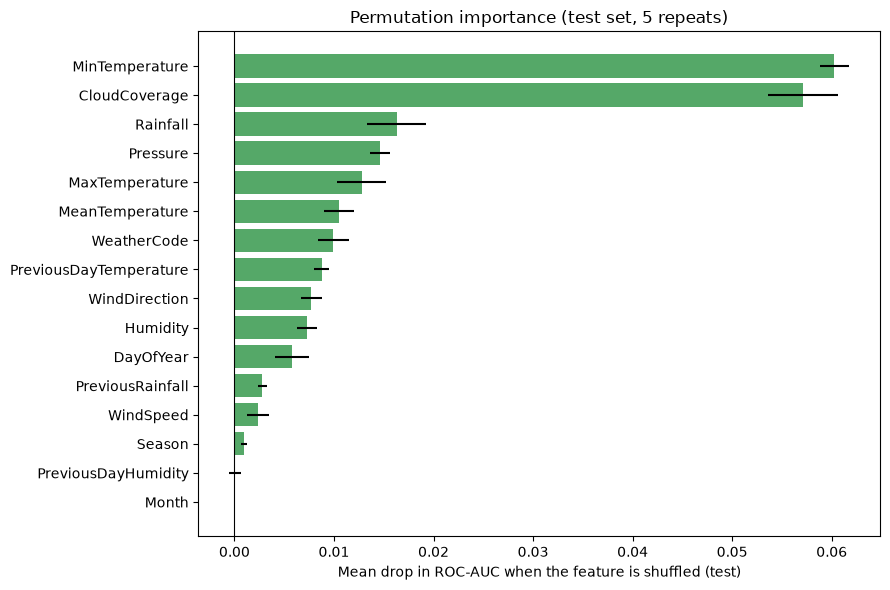

Saved -> G:\Machine Learning Models\1st Model\reports\figures\09_permutation_importance.png


In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(perm["feature"], perm["importance_mean"], xerr=perm["importance_std"], color="#55A868")
ax.invert_yaxis()
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Mean drop in ROC-AUC when the feature is shuffled (test)")
ax.set_title("Permutation importance (test set, 5 repeats)")
plt.tight_layout()

out = BASE / "reports" / "figures" / "09_permutation_importance.png"
plt.savefig(out, dpi=120, bbox_inches="tight")
plt.show()
print("Saved ->", out)

## 3. Do the two measures agree?

In [6]:
# Impurity importance is post-transform (Season split into 4 one-hot
# columns); aggregate them so both measures speak in the same 16 features.
raw_imp = imp.copy()
raw_imp["feature"] = raw_imp["feature"].where(
    ~raw_imp["feature"].str.startswith("Season_"), "Season"
)
raw_imp = raw_imp.groupby("feature", as_index=False)["importance"].sum()

rank = raw_imp.merge(perm, on="feature", how="outer")
rank["imp_rank"] = rank["importance"].rank(ascending=False, method="min").astype(int)
rank["perm_rank"] = rank["importance_mean"].rank(ascending=False, method="min").astype(int)
rank.sort_values("imp_rank")[["feature", "importance", "imp_rank", "importance_mean", "importance_std", "perm_rank"]]

,feature,importance,imp_rank,importance_mean,importance_std,perm_rank
13,WeatherCode,0.295767,1,0.009929,0.001565,7
11,Rainfall,0.229425,2,0.016296,0.002949,3
0,CloudCoverage,0.134500,3,0.057140,0.003526,2
7,Pressure,0.055524,4,0.014655,0.001020,4
15,WindSpeed,0.046222,5,0.002395,0.001126,13
1,DayOfYear,0.040519,6,0.005778,0.001673,11
14,WindDirection,0.036328,7,0.007732,0.001051,9
5,MinTemperature,0.034436,8,0.060258,0.001479,1
3,MaxTemperature,0.028495,9,0.012770,0.002485,5
10,PreviousRainfall,0.025895,10,0.002804,0.000432,12


## 4. Error analysis — where does the champion go wrong?

At threshold 0.25 the model faces 3,040 test days. We tag every row as a hit, a miss, a
false alarm, or a correct no-rain, then look at where the mistakes cluster.

In [7]:
err = error_frame(pipe, X_test, y_test, threshold)
err["type"].value_counts()

type
correct no-rain      2080
hit (rain caught)     567
false alarm (FP)      206
miss (FN)             187
Name: count, dtype: int64

In [8]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, err["prediction"])
pd.DataFrame(cm, index=["actual no-rain", "actual rain"], columns=["pred no-rain", "pred rain"])

,pred no-rain,pred rain
actual no-rain,2080,206
actual rain,187,567


## 5. Errors by season and month

Rain in Karachi is seasonal (monsoon = Jun-Sep). Does the model's accuracy follow, or does
it fail exactly when it matters most?

In [9]:
err_by_season = error_breakdown(X_test, err, "Season")
err_by_season

,days,rainy,rain_rate,predicted_rain,misses,miss_rate_of_rain,false_alarms,fp_per_day
Season,,,,,,,,
HotDry,783,51,0.065134,33,38,0.745098,20,0.025543
Monsoon,1047,626,0.597899,691,99,0.158147,164,0.156638
PostMonsoon,488,32,0.065574,25,19,0.593750,12,0.024590
Winter,722,45,0.062327,24,31,0.688889,10,0.013850


In [10]:
err_by_month = error_breakdown(X_test, err, "Month").reindex(range(1, 13))
err_by_month

,days,rainy,rain_rate,predicted_rain,misses,miss_rate_of_rain,false_alarms,fp_per_day
Month,,,,,,,,
1,248,20,0.080645,11,14,0.700000,5,0.020161
2,226,16,0.070796,8,12,0.750000,4,0.017699
3,248,16,0.064516,10,12,0.750000,6,0.024194
4,256,15,0.058594,7,12,0.800000,4,0.015625
5,279,20,0.071685,16,14,0.700000,10,0.035842
6,270,134,0.496296,145,28,0.208955,39,0.144444
7,279,214,0.767025,246,17,0.079439,49,0.175627
8,258,201,0.779070,213,26,0.129353,38,0.147287
9,240,77,0.320833,87,28,0.363636,38,0.158333


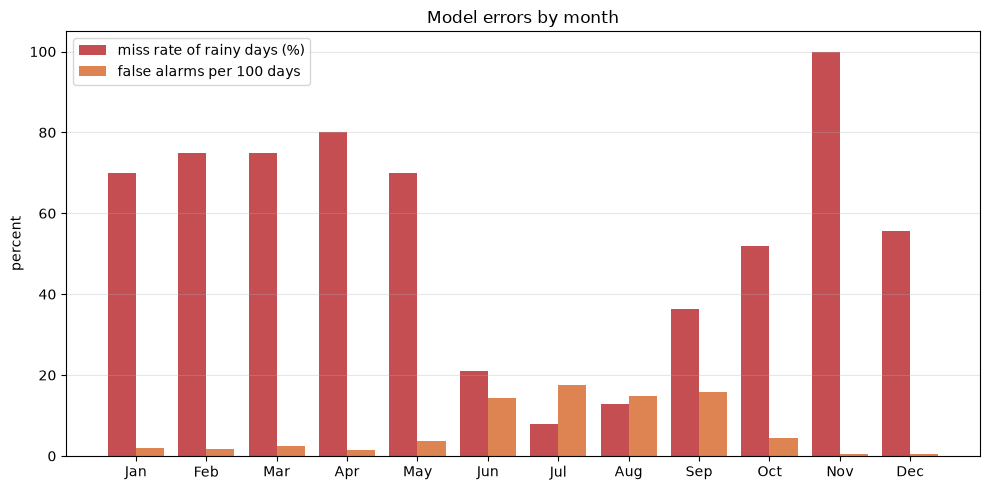

Saved -> G:\Machine Learning Models\1st Model\reports\figures\09_errors_by_month.png


In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
width = 0.4
ax.bar(err_by_month.index - width / 2, err_by_month["miss_rate_of_rain"] * 100, width,
       label="miss rate of rainy days (%)", color="#C44E52")
ax.bar(err_by_month.index + width / 2, err_by_month["fp_per_day"] * 100, width,
       label="false alarms per 100 days", color="#DD8452")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
ax.set_ylabel("percent")
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.set_title("Model errors by month")
plt.tight_layout()

out = BASE / "reports" / "figures" / "09_errors_by_month.png"
plt.savefig(out, dpi=120, bbox_inches="tight")
plt.show()
print("Saved ->", out)

## 6. Errors over time — does the model drift?

The test set spans 2018-2026. If the miss rate creeps up in later years, the model is
decaying (the future stopped looking like the training past).

In [12]:
features = pd.read_csv(BASE / "data" / "processed" / "karachi_weather_features.csv",
                      parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)
split_idx = int(len(features) * 0.8)
dates_test = features.loc[split_idx:, "Date"].reset_index(drop=True)

err_t = err.copy()
err_t["Date"] = dates_test
err_t["Year"] = err_t["Date"].dt.year
err_t["miss"] = ((err_t["y_true"] == 1) & (err_t["prediction"] == 0)).astype(int)
err_t["false_alarm"] = ((err_t["y_true"] == 0) & (err_t["prediction"] == 1)).astype(int)

by_year = err_t.groupby("Year").agg(
    days=("Date", "size"),
    rainy=("y_true", "sum"),
    misses=("miss", "sum"),
    false_alarms=("false_alarm", "sum"),
)
by_year["miss_rate_of_rain"] = by_year["misses"] / by_year["rainy"]
by_year["fp_per_day"] = by_year["false_alarms"] / by_year["days"]
by_year

,days,rainy,misses,false_alarms,miss_rate_of_rain,fp_per_day
Year,,,,,,
2018,261,62,15,24,0.241935,0.091954
2019,365,99,37,27,0.373737,0.073973
2020,366,78,19,22,0.243590,0.060109
2021,365,83,18,27,0.216867,0.073973
2022,365,99,17,9,0.171717,0.024658
2023,365,98,23,28,0.234694,0.076712
2024,366,77,20,27,0.259740,0.073770
2025,365,99,17,17,0.171717,0.046575
2026,222,59,21,25,0.355932,0.112613


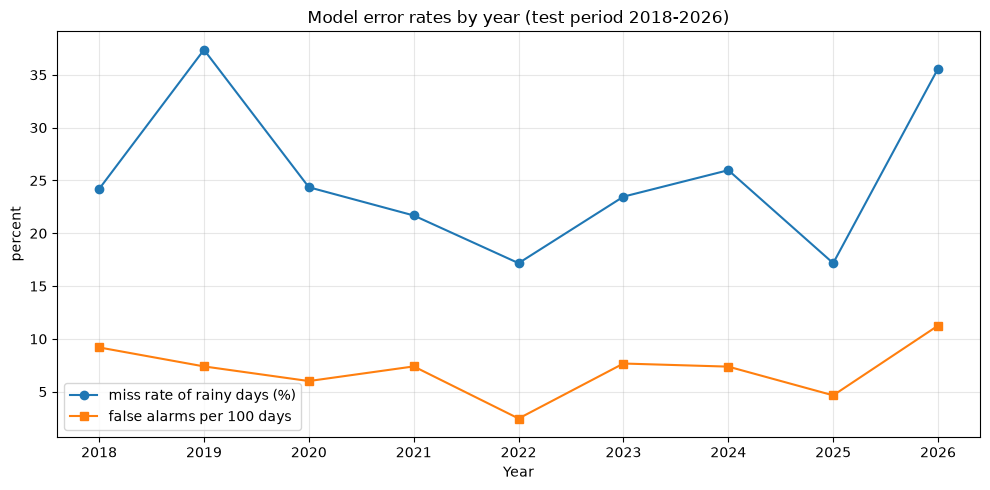

Saved -> G:\Machine Learning Models\1st Model\reports\figures\09_errors_over_time.png


In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(by_year.index, by_year["miss_rate_of_rain"] * 100, marker="o", label="miss rate of rainy days (%)")
ax.plot(by_year.index, by_year["fp_per_day"] * 100, marker="s", label="false alarms per 100 days")
ax.set_xlabel("Year")
ax.set_ylabel("percent")
ax.legend()
ax.grid(alpha=0.3)
ax.set_title("Model error rates by year (test period 2018-2026)")
plt.tight_layout()

out = BASE / "reports" / "figures" / "09_errors_over_time.png"
plt.savefig(out, dpi=120, bbox_inches="tight")
plt.show()
print("Saved ->", out)

## 7. Error signatures — what do missed days look like?

Compare the average feature values of the four outcome groups. If missed rainy days look
like *dry* days (low humidity, clear sky), the model has no signal to catch them — an honest
limit of the features. If they look almost like caught days, the boundary is simply hard.

In [14]:
sig_cols = ["Humidity", "CloudCoverage", "Pressure", "MaxTemperature", "MinTemperature",
           "WindSpeed", "PreviousRainfall"]
sig = X_test.reset_index(drop=True).copy()
sig["type"] = err["type"].values
sig.groupby("type")[sig_cols].mean().round(2)

,Humidity,CloudCoverage,Pressure,MaxTemperature,MinTemperature,WindSpeed,PreviousRainfall
type,,,,,,,
correct no-rain,63.58,17.88,1011.09,29.90,21.38,21.75,0.12
false alarm (FP),76.15,61.71,1002.60,31.50,26.99,24.92,2.36
hit (rain caught),79.05,68.95,1001.31,31.15,27.32,26.16,2.84
miss (FN),73.82,40.06,1006.12,30.16,24.69,23.30,1.03


## 8. Takeaway

In [15]:
print("Top 3 features by permutation importance:")
for _, r in perm.head(3).iterrows():
    print(f"  {r['feature']:22s} AUC drop {r['importance_mean']:.4f} +/- {r['importance_std']:.4f}")

worst_miss = err_by_month["miss_rate_of_rain"].idxmax()
print(f"Highest miss month: {worst_miss} ({err_by_month.loc[worst_miss, 'miss_rate_of_rain']:.0%} of its rainy days missed)")
worst_fp = err_by_month["fp_per_day"].idxmax()
print(f"Highest false-alarm month: {worst_fp} ({err_by_month.loc[worst_fp, 'fp_per_day']:.1%} of its days were false alarms)")

drift = by_year["miss_rate_of_rain"]
print(f"Miss rate 2018: {drift.iloc[0]:.0%} | {drift.index[-1]}: {drift.iloc[-1]:.0%}")

Top 3 features by permutation importance:
  MinTemperature         AUC drop 0.0603 +/- 0.0015
  CloudCoverage          AUC drop 0.0571 +/- 0.0035
  Rainfall               AUC drop 0.0163 +/- 0.0029
Highest miss month: 11 (100% of its rainy days missed)
Highest false-alarm month: 7 (17.6% of its days were false alarms)
Miss rate 2018: 24% | 2026: 36%


The numbers above are the honest summary. The value of this phase is the *why*:

- **What drives the model** — today's weather (WeatherCode, Rainfall, cloud) dominates; calendar
  and yesterday features are minor contributors. Any feature engineering for Phase 10+ should
  focus there.
- **Where it fails** — the season and month tables show exactly which months bleed the most
  false alarms (often the start/end of the monsoon, when the sky is ambiguous) and which rainy
  days it still misses.
- **Drift** — the by-year plot answers "is the 2018-2026 test still trustworthy?" A rising miss
  rate would argue for periodic retraining in the real deployment.

Next: Phase 10 turns the champion into a usable service (`src/predict.py`, FastAPI, Streamlit).